
# Build a Conditional GAN

In [1]:
import torch
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np

### Generator and Noise

In [2]:
class Generator(nn.Module):
    def __init__(self, input_dim=10, im_chan=1, hidden_dim=64):
        super(Generator, self).__init__()
        self.input_dim = input_dim
        self.gen = nn.Sequential(
            self.make_gen_block(input_dim, hidden_dim * 4),
            self.make_gen_block(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=1),
            self.make_gen_block(hidden_dim * 2, hidden_dim),
            self.make_gen_block(hidden_dim, im_chan, kernel_size=4, final_layer=True),
        )

    def make_gen_block(self, input_channels, output_channels, kernel_size=3, stride=2, final_layer=False):

        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace=True),
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.Tanh(),
            )

    def forward(self, noise):
        x = noise.view(len(noise), self.input_dim, 1, 1)
        return self.gen(x)

def get_noise(n_samples, input_dim, device='cpu'):
    return torch.randn(n_samples, input_dim, device=device)

### Discriminator

In [3]:
class Discriminator(nn.Module):
    def __init__(self, im_chan=1, hidden_dim=64):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            self.make_disc_block(im_chan, hidden_dim),
            self.make_disc_block(hidden_dim, hidden_dim * 2),
            self.make_disc_block(hidden_dim * 2, 1, final_layer=True),
        )

    def make_disc_block(self, input_channels, output_channels, kernel_size=4, stride=2, final_layer=False):
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace=True),
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
            )

    def forward(self, image):
        disc_pred = self.disc(image)
        return disc_pred.view(len(disc_pred), -1)

### Class Input

In [4]:
import torch.nn.functional as F
def get_one_hot_labels(labels, n_classes):
    return F.one_hot(labels,n_classes)

In [5]:
def combine_vectors(x, y):
    combined = torch.cat((x.float(),y.float()), 1)
    return combined

### Training

In [6]:
mnist_shape = (1, 28, 28)
n_classes = 10

In [7]:
criterion = nn.BCEWithLogitsLoss()
n_epochs = 200
z_dim = 64
display_step = 500
batch_size = 128
lr = 0.0002
device = 'cuda'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataloader = DataLoader(
    MNIST('.', download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.36MB/s]


In [8]:
def get_input_dimensions(z_dim, mnist_shape, n_classes):
    generator_input_dim = z_dim + n_classes
    discriminator_im_chan = mnist_shape[0] + n_classes
    return generator_input_dim, discriminator_im_chan

In [9]:
generator_input_dim, discriminator_im_chan = get_input_dimensions(z_dim, mnist_shape, n_classes)

gen = Generator(input_dim=generator_input_dim).to(device)
gen_opt = torch.optim.Adam(gen.parameters(), lr=lr)
disc = Discriminator(im_chan=discriminator_im_chan).to(device)
disc_opt = torch.optim.Adam(disc.parameters(), lr=lr)

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)
gen = gen.apply(weights_init)
disc = disc.apply(weights_init)

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0 Loss D: 0.9157 | Loss G: 8.3585


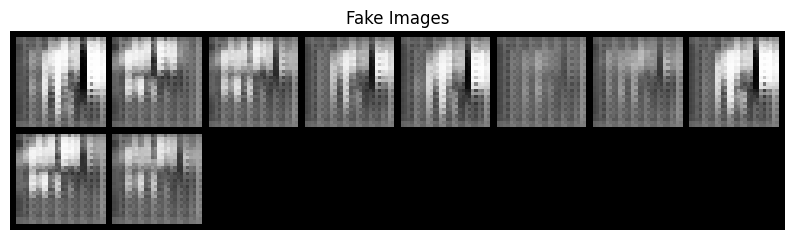

Epoch 10 Loss D: 1.5517 | Loss G: 6.5619


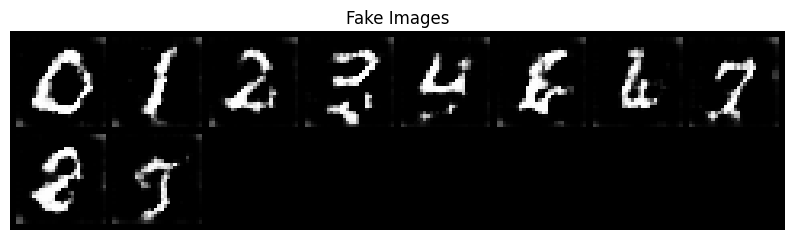

Epoch 20 Loss D: 1.9666 | Loss G: 4.4557


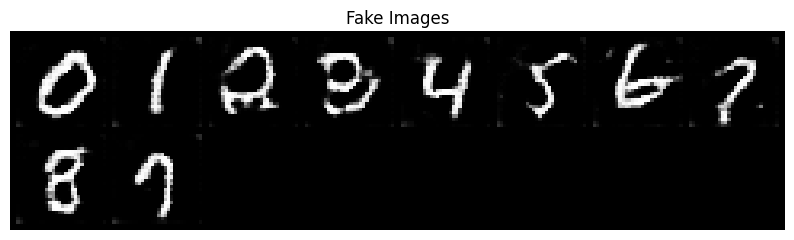

Epoch 30 Loss D: 2.0630 | Loss G: 4.2020


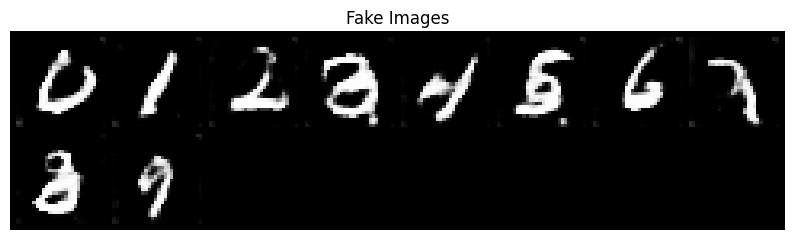

Epoch 40 Loss D: 2.0728 | Loss G: 3.9213


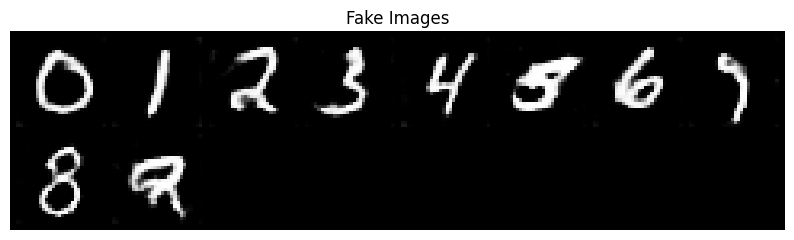

Epoch 50 Loss D: 2.1024 | Loss G: 3.9469


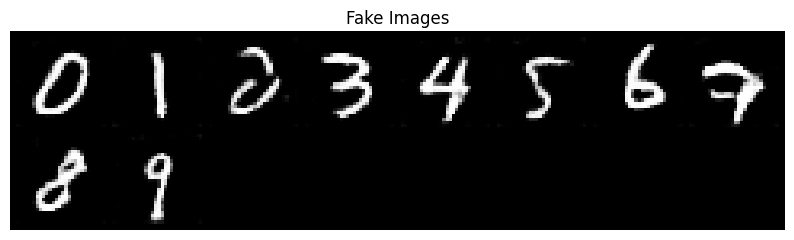

Epoch 60 Loss D: 2.1290 | Loss G: 3.8795


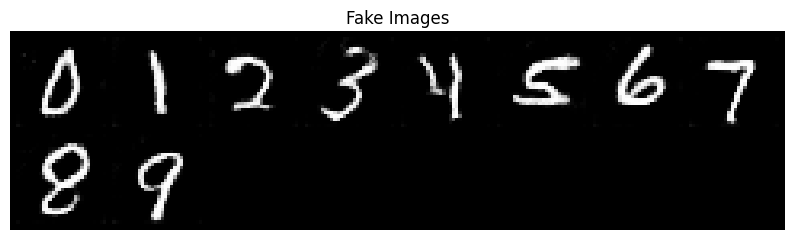

Epoch 70 Loss D: 2.1699 | Loss G: 3.7857


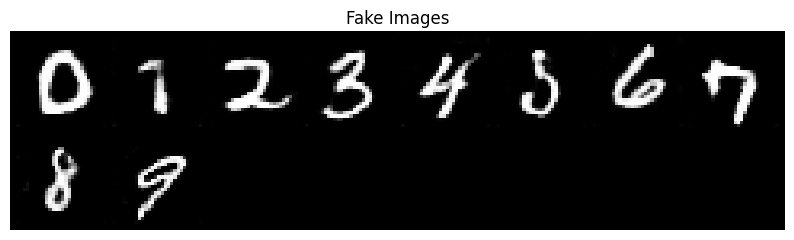

Epoch 80 Loss D: 2.1330 | Loss G: 3.7314


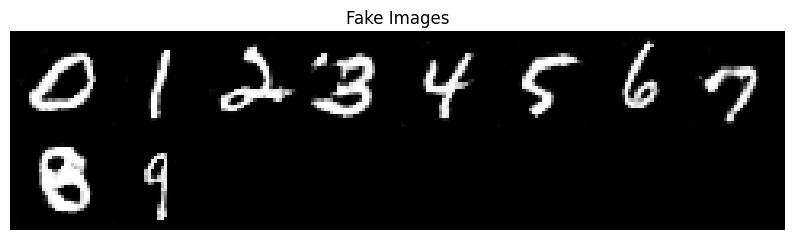

Epoch 90 Loss D: 2.1024 | Loss G: 3.7809


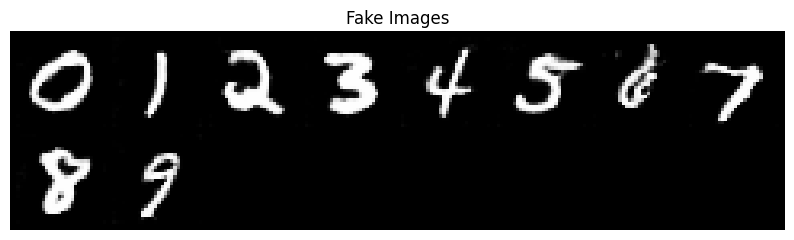

Epoch 100 Loss D: 2.1254 | Loss G: 3.8822


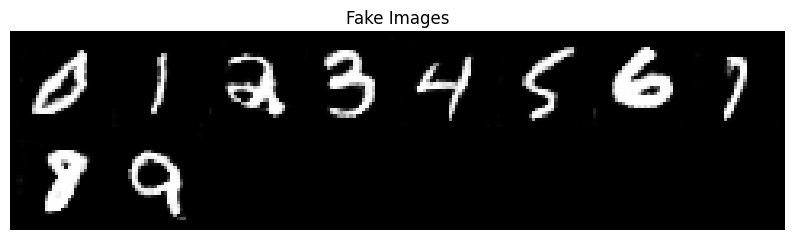

Epoch 110 Loss D: 2.0900 | Loss G: 3.8920


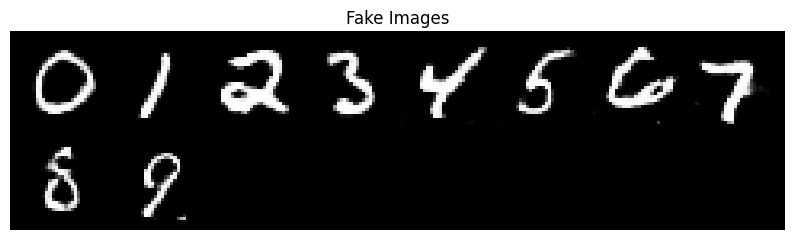

Epoch 120 Loss D: 2.0965 | Loss G: 3.9114


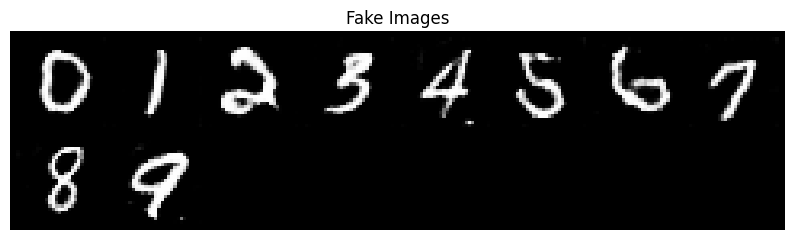

Epoch 130 Loss D: 2.0858 | Loss G: 3.8643


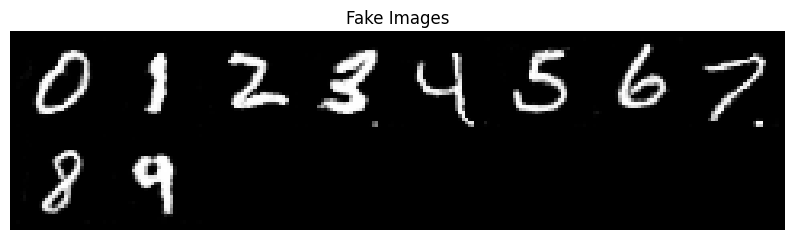

Epoch 140 Loss D: 2.1084 | Loss G: 3.9280


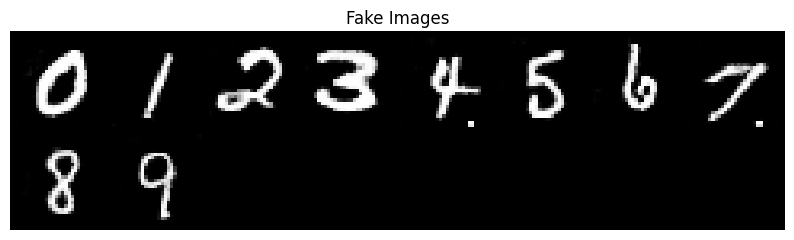

Epoch 150 Loss D: 2.1184 | Loss G: 3.8708


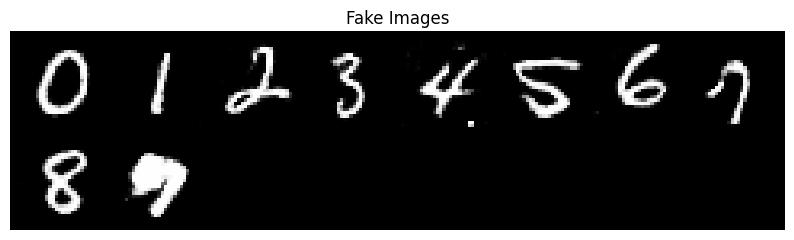

Epoch 160 Loss D: 2.1140 | Loss G: 3.9518


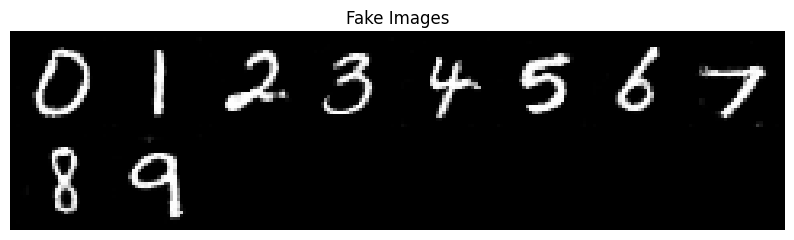

Epoch 170 Loss D: 2.1010 | Loss G: 3.9453


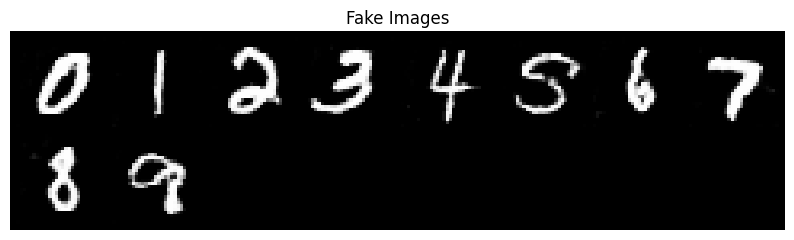

Epoch 180 Loss D: 2.1310 | Loss G: 3.9360


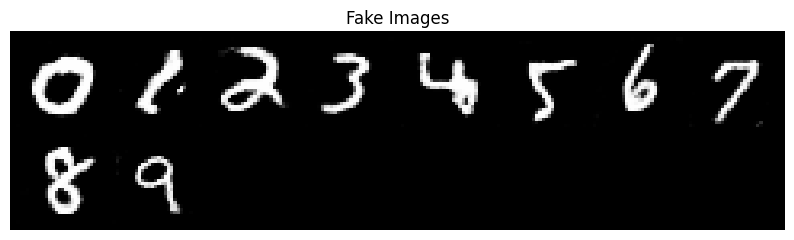

Epoch 190 Loss D: 2.1431 | Loss G: 3.9349


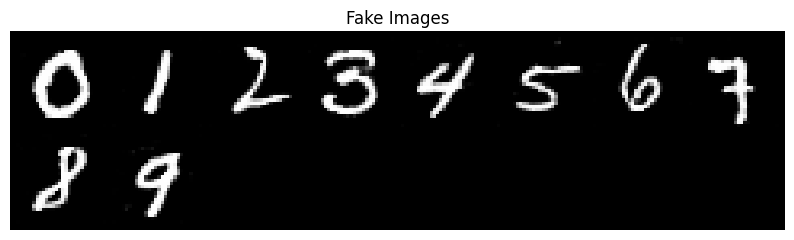

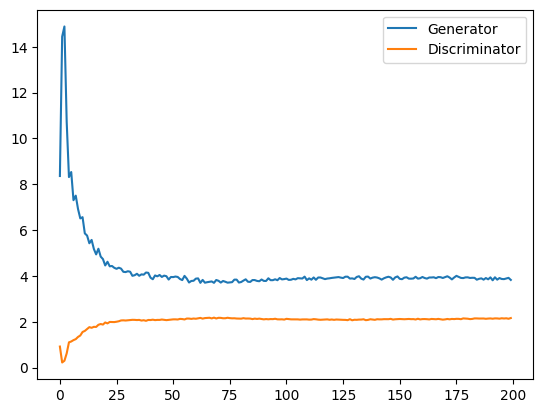

In [10]:
generator_losses = []
discriminator_losses = []

for epoch in tqdm(range(n_epochs)):
    mean_disc_loss=0
    mean_gen_loss=0
    for real, labels in dataloader:
        cur_batch_size = len(real)
        real = real.to(device)

        one_hot_labels = get_one_hot_labels(labels.to(device), n_classes)
        image_one_hot_labels = one_hot_labels[:, :, None, None]
        image_one_hot_labels = image_one_hot_labels.repeat(1, 1, mnist_shape[1], mnist_shape[2])

        ### Update discriminator ###
        disc_opt.zero_grad()
        fake_noise = get_noise(cur_batch_size, z_dim, device=device)

        noise_and_labels = combine_vectors(fake_noise, one_hot_labels)
        fake = gen(noise_and_labels)

        fake_image_and_labels = combine_vectors(fake, image_one_hot_labels)
        real_image_and_labels = combine_vectors(real, image_one_hot_labels)
        disc_fake_pred = disc(fake_image_and_labels.detach())
        disc_real_pred = disc(real_image_and_labels)

        disc_fake_loss = criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))
        disc_real_loss = criterion(disc_real_pred, torch.ones_like(disc_real_pred))
        disc_loss = (disc_fake_loss + disc_real_loss) / 2
        disc_loss.backward()
        disc_opt.step()

        ### Update generator ###
        gen_opt.zero_grad()
        fake_image_and_labels = combine_vectors(fake, image_one_hot_labels)
        disc_fake_pred = disc(fake_image_and_labels)
        gen_loss = criterion(disc_fake_pred, torch.ones_like(disc_fake_pred))
        gen_loss.backward()
        gen_opt.step()

        mean_disc_loss+=disc_loss.item()/cur_batch_size
        mean_gen_loss+=gen_loss.item()/cur_batch_size

    generator_losses += [mean_gen_loss]
    discriminator_losses += [mean_disc_loss]

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss D: {mean_disc_loss:.4f} | Loss G: {mean_gen_loss:.4f}")

        fake_noise = get_noise(10, z_dim, device=device)
        labels=torch.tensor([num for num in range(10)]).to(device)
        one_hot_labels = get_one_hot_labels(labels.to(device), n_classes)

        noise_and_labels = combine_vectors(fake_noise, one_hot_labels)
        fake = gen(noise_and_labels)
        grid = vutils.make_grid(fake.detach().cpu(), padding=2, normalize=True)

        plt.figure(figsize=(10, 10))
        plt.axis("off")
        plt.title("Fake Images")
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        plt.show()

plt.plot(generator_losses, label="Generator")
plt.plot(discriminator_losses, label="Discriminator")
plt.legend()
plt.show()

